In [1]:
!pip install matplotlib numpy

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from queue import PriorityQueue

In [3]:
# Grid size
GRID_SIZE = 20

# Create empty grid
grid = np.zeros((GRID_SIZE, GRID_SIZE))

# Start and Goal
start = (0, 0)
goal = (19, 19)

print("Grid Created Successfully")

Grid Created Successfully


In [4]:
import random

# Add random obstacles
for _ in range(60):
    x = random.randint(0, 19)
    y = random.randint(0, 19)

    # Avoid start and goal
    if (x, y) != start and (x, y) != goal:
        grid[x][y] = 1

print("Obstacles Added")

Obstacles Added


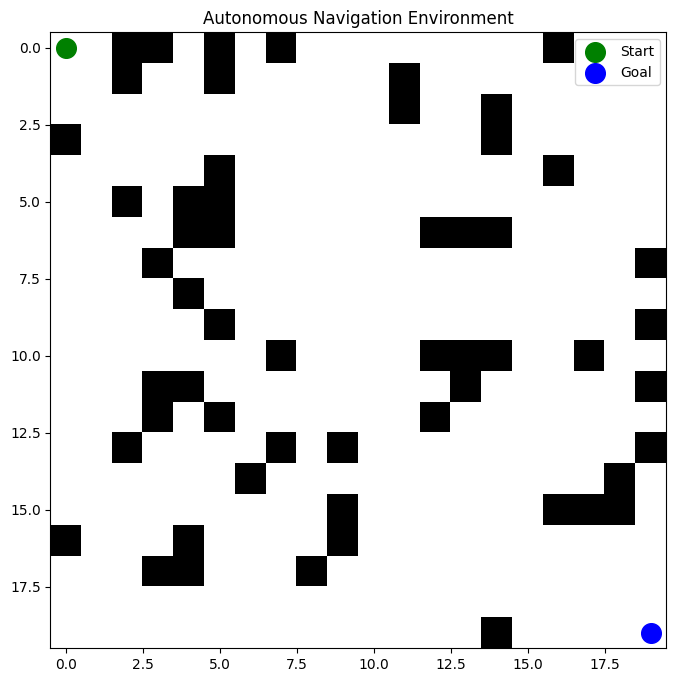

In [5]:
plt.figure(figsize=(8,8))

# Show grid
plt.imshow(grid, cmap='gray_r')

# Show start point
plt.scatter(start[1], start[0], color='green', s=200, label='Start')

# Show goal point
plt.scatter(goal[1], goal[0], color='blue', s=200, label='Goal')

plt.title("Autonomous Navigation Environment")
plt.legend()

plt.show()

In [6]:
def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def astar(grid, start, goal):

    rows, cols = grid.shape

    open_set = PriorityQueue()
    open_set.put((0, start))

    came_from = {}

    g_score = {start: 0}

    while not open_set.empty():

        current = open_set.get()[1]

        if current == goal:

            path = []

            while current in came_from:
                path.append(current)
                current = came_from[current]

            path.append(start)
            path.reverse()

            return path

        neighbors = [
            (current[0]+1, current[1]),
            (current[0]-1, current[1]),
            (current[0], current[1]+1),
            (current[0], current[1]-1)
        ]

        for neighbor in neighbors:

            x, y = neighbor

            if x < 0 or y < 0 or x >= rows or y >= cols:
                continue

            if grid[x][y] == 1:
                continue

            temp_g = g_score[current] + 1

            if neighbor not in g_score or temp_g < g_score[neighbor]:

                came_from[neighbor] = current
                g_score[neighbor] = temp_g

                f_score = temp_g + heuristic(neighbor, goal)

                open_set.put((f_score, neighbor))

    return None

In [7]:
path = astar(grid, start, goal)

if path:
    print("Path Found Successfully!")
    print("Path Length:", len(path))
else:
    print("No Path Found")

Path Found Successfully!
Path Length: 39


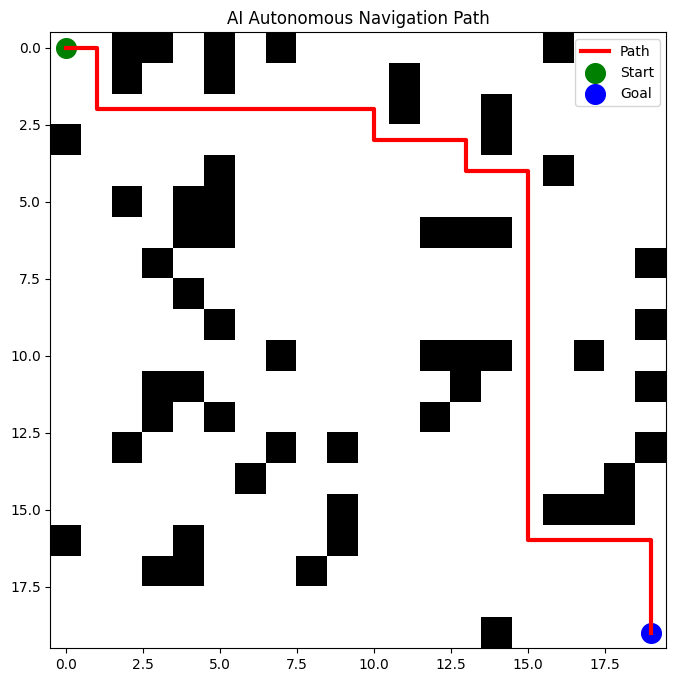

In [8]:
plt.figure(figsize=(8,8))

plt.imshow(grid, cmap='gray_r')

# Draw path
if path:
    path_x = [p[1] for p in path]
    path_y = [p[0] for p in path]

    plt.plot(path_x, path_y, color='red', linewidth=3, label='Path')

# Start
plt.scatter(start[1], start[0], color='green', s=200, label='Start')

# Goal
plt.scatter(goal[1], goal[0], color='blue', s=200, label='Goal')

plt.title("AI Autonomous Navigation Path")

plt.legend()

plt.show()

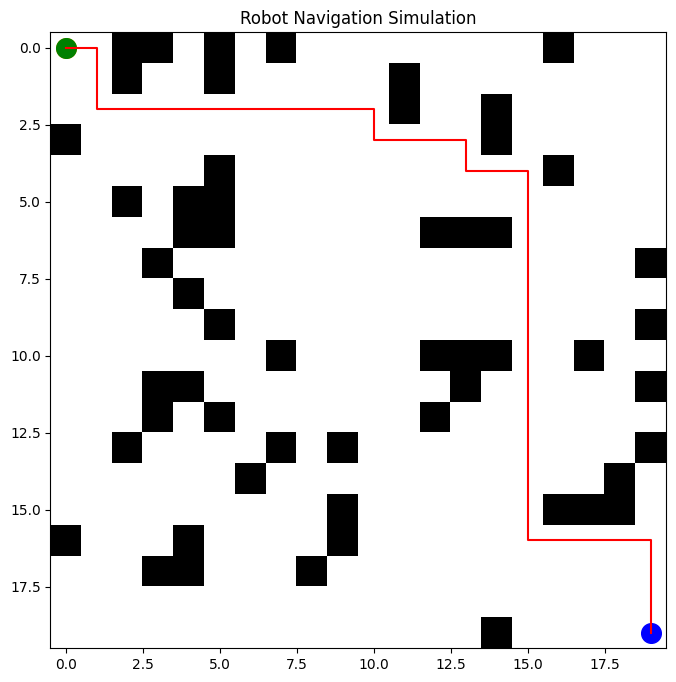

In [9]:
from matplotlib import animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(8,8))

def update(frame):

    ax.clear()

    ax.imshow(grid, cmap='gray_r')

    # Draw path
    path_x = [p[1] for p in path]
    path_y = [p[0] for p in path]

    ax.plot(path_x, path_y, color='red')

    # Robot current position
    current = path[frame]

    ax.scatter(current[1], current[0],
               color='orange',
               s=200,
               label='Robot')

    ax.scatter(start[1], start[0],
               color='green',
               s=200)

    ax.scatter(goal[1], goal[0],
               color='blue',
               s=200)

    ax.set_title("Robot Navigation Simulation")

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(path),
    interval=300
)

HTML(ani.to_jshtml())

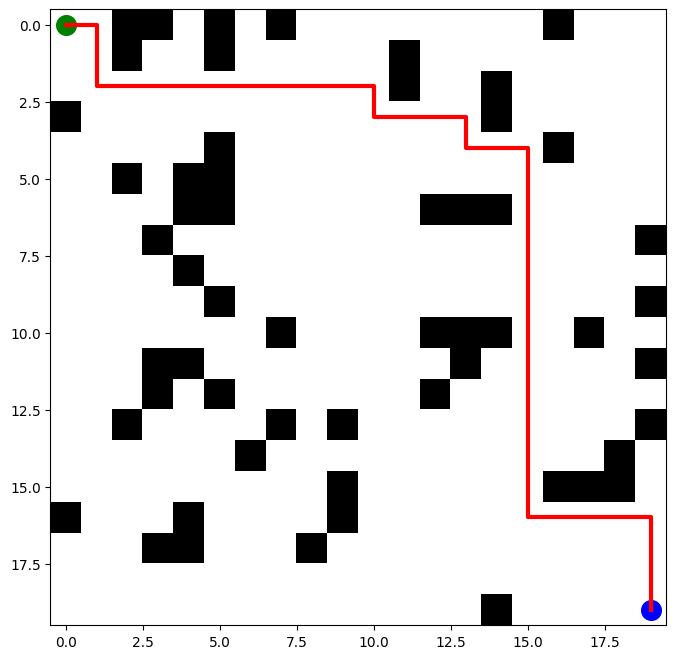

In [10]:
plt.figure(figsize=(8,8))

plt.imshow(grid, cmap='gray_r')

path_x = [p[1] for p in path]
path_y = [p[0] for p in path]

plt.plot(path_x, path_y, color='red', linewidth=3)

plt.scatter(start[1], start[0], color='green', s=200)
plt.scatter(goal[1], goal[0], color='blue', s=200)

plt.savefig("autonomous_navigation_result.png")

plt.show()